In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")



In [ ]:
# Load Dataset

df = pd.read_csv("../data/raw_dataset.csv")
df.head()


,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [5]:
# Basic Data Inspection

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB


,Unnamed: 0,open,high,low,close,volume,marketCap
count,72946.000000,72946.000000,7.294600e+04,72946.000000,7.294600e+04,7.294600e+04,7.294600e+04
mean,36472.500000,870.194495,8.964124e+02,844.060640,8.712949e+02,2.207607e+09,1.474922e+10
std,21057.840705,5231.654470,5.398613e+03,5079.389387,5.235508e+03,9.617885e+09,7.501159e+10
min,0.000000,0.000000,1.022100e-10,0.000000,8.292000e-11,0.000000e+00,0.000000e+00
25%,18236.250000,0.167916,1.767999e-01,0.158630,1.682982e-01,8.320618e+06,1.860432e+08
50%,36472.500000,1.630666,1.717542e+00,1.541486,1.640219e+00,1.098756e+08,1.268539e+09
75%,54708.750000,26.070557,2.756868e+01,24.791776,2.625195e+01,6.691398e+08,5.118618e+09
max,72945.000000,67549.735581,1.621883e+05,66458.723733,6.756683e+04,3.509679e+11,1.274831e+12


In [ ]:
# Data Cleaning

# Drop unnecessary column
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort values for time series
df.sort_values(by=['crypto_name', 'date'], inplace=True)

# Handle missing values (forward fill)
df.ffill(inplace=True)


In [ ]:
# Feature Engineering – Volatility Creation

## Log Returns
df['log_return'] = np.log(df['close'] / df['close'].shift(1))



In [9]:
## Rolling Volatility (TARGET)
df['volatility_7d'] = df['log_return'].rolling(window=7).std()

In [10]:
# Additional Features

df['price_range'] = df['high'] - df['low']
df['close_open_diff'] = df['close'] - df['open']
df['volume_marketcap_ratio'] = df['volume'] / df['marketCap']

df['ma_7'] = df['close'].rolling(7).mean()
df['ma_14'] = df['close'].rolling(14).mean()


In [11]:
# Drop NA values after rolling calculations

df.dropna(inplace=True)


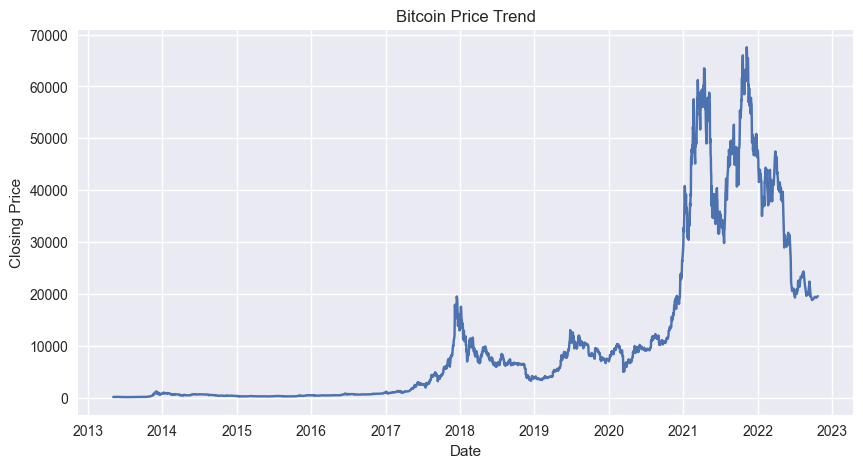

In [12]:
# Exploratory Data Analysis (EDA)

## Price Trend

plt.figure(figsize=(10,5))
plt.plot(df[df['crypto_name']=="Bitcoin"]['date'],
         df[df['crypto_name']=="Bitcoin"]['close'])
plt.title("Bitcoin Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()


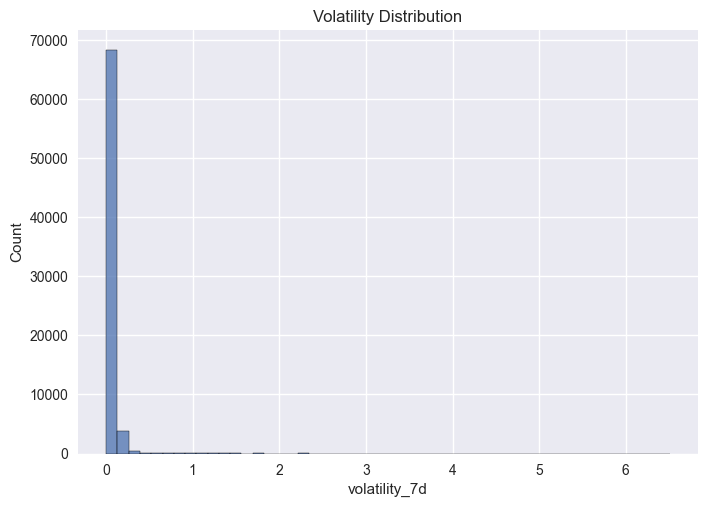

In [13]:
## Volatility Distribution

sns.histplot(df['volatility_7d'], bins=50)
plt.title("Volatility Distribution")
plt.show()



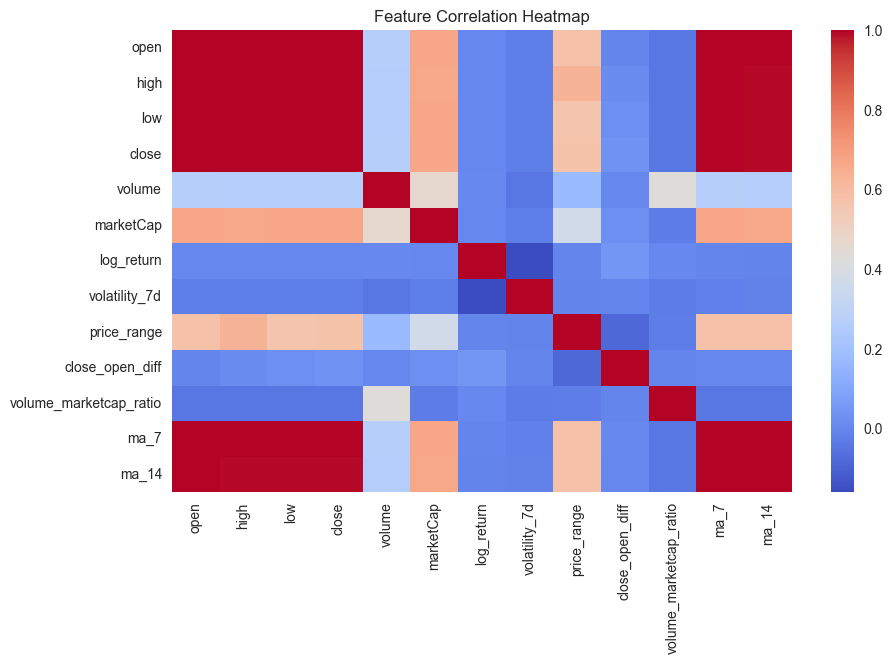

In [14]:
## Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [15]:
# Save Processed Dataset

df.to_csv("../data/processed_dataset.csv", index=False)